# **1: Data Pre-Processing**

## **1.1** DEPENDENCIES INSTALLATION

In [ ]:
!pip install wfdb
!pip install PyWavelets
!pip install mne
!pip install pykalman
!pip install numpy scipy matplotlib pywt pyemd opencv-python
!pip install PyEMD==1.0.0
!pip install tensorflow-addons==0.22.0
!pip install keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 88.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 12.7 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pywt (from versions: none)
ERROR: No matc

In [ ]:
import os
import re
import cv2
import wfdb
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import (
    butter, filtfilt, medfilt, savgol_filter, find_peaks, iirnotch,
    resample, lfilter, spectrogram, hilbert
)
from scipy.ndimage import gaussian_filter1d
from scipy.fft import fft, ifft
from scipy.fftpack import dct
from scipy.interpolate import interp1d, CubicSpline, BarycentricInterpolator
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA, FastICA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from pykalman import KalmanFilter
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.colab.patches import cv2_imshow


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **1.2** DATA PRE-PROCESSING (NOISE REMOVAL)

In [ ]:
lowcut = 0.5
highcut = 50.0
sampling_rate = 1000

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

def process_ecg_files(file_list, sampling_rate, lowcut, highcut):
    all_filtered_signals = pd.DataFrame()

    for file_path in file_list:
        try:
            data = pd.read_csv(file_path)

            for column in data.columns:
                ecg_signal = data[column].values
                filtered_signal = apply_bandpass_filter(ecg_signal, lowcut, highcut, sampling_rate)
                all_filtered_signals[f"{os.path.basename(file_path)}_{column}_filtered"] = filtered_signal

            print(f"Processed file: {file_path}")
        except Exception as e:
            print(f"Error processing file {file_path}: {str(e)}")

    return all_filtered_signals

# List of ECG files to process
file_list = [
    '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/EXTRACTED DATA PTB/Myocardial infarction/ii_df.csv'
]

# Process files and apply bandpass filter
filtered_ecg_signals_df = process_ecg_files(file_list, sampling_rate, lowcut, highcut)

# Save filtered signals to CSV
output_file = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv'
filtered_ecg_signals_df.to_csv(output_file, index=False)
print(f"Filtered signals saved to {output_file}")

Processed file: /content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/EXTRACTED DATA PTB/Myocardial infarction/ii_df.csv
Filtered signals saved to /content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv


## **1.3** DATA PRE-PROCESSING (DATA SEGMENTATION)

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

def pan_tompkins_qrs_detection(ecg_signal, sampling_rate):
    # Step 1: Differentiation
    diff_ecg = np.diff(ecg_signal)

    # Step 2: Squaring
    squared_ecg = diff_ecg ** 2

    # Step 3: Moving average integration
    window_size = int(0.15 * sampling_rate)  # 150 ms window
    integrated_ecg = np.convolve(squared_ecg, np.ones(window_size) / window_size, mode='same')

    # Step 4: Thresholding
    threshold = np.percentile(integrated_ecg, 95)  # Adjust percentile as needed

    # Step 5: Peak detection
    r_peaks, _ = find_peaks(integrated_ecg, height=threshold, distance=int(sampling_rate * 0.6))

    return r_peaks, integrated_ecg

def segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size):
    half_window = int(window_size * sampling_rate / 2)
    segments = []

    for r_peak in r_peaks:
        start = max(0, r_peak - half_window)
        end = min(len(ecg_signal), r_peak + half_window)
        segment = ecg_signal[start:end]

        # Pad the segment if it is shorter than the window size
        if len(segment) < 2 * half_window:
            segment = np.pad(segment, (0, max(0, 2 * half_window - len(segment))), mode='constant')

        segments.append(segment)

    return segments

def process_ecg_segmentation(input_csv, output_csv, sampling_rate=1000, window_size=5):
    ecg_data = pd.read_csv(input_csv)
    all_segments = []

    # Iterate over PATIENTS (columns)
    for patient_col in ecg_data.columns:  # Each column = patient
        ecg_signal = ecg_data[patient_col].dropna().values
        r_peaks, _ = pan_tompkins_qrs_detection(ecg_signal, sampling_rate)

        # Segment ECG for this patient
        segments = segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size)

        # Store segments with patient ID
        for seg in segments:
            all_segments.append({
                "patient_id": patient_col,
                "ecg_segment": seg.tolist()  # Store as list for DataFrame
            })

    # Create DataFrame with patient-segment mapping
    segments_df = pd.DataFrame(all_segments)
    segments_df.to_csv(output_csv, index=False)

if __name__ == "__main__":
    input_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv'
    output_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/segmentation_MI.csv'

    process_ecg_segmentation(input_csv, output_csv)

In [ ]:
# import os
# import numpy as np
# import pandas as pd
# from scipy.signal import find_peaks

# def pan_tompkins_qrs_detection(ecg_signal, sampling_rate):
#     # Step 1: Differentiation
#     diff_ecg = np.diff(ecg_signal)

#     # Step 2: Squaring
#     squared_ecg = diff_ecg ** 2

#     # Step 3: Moving average integration
#     window_size = int(0.15 * sampling_rate)  # 150 ms window
#     integrated_ecg = np.convolve(squared_ecg, np.ones(window_size) / window_size, mode='same')

#     # Step 4: Thresholding
#     threshold = np.percentile(integrated_ecg, 95)  # Adjust percentile as needed

#     # Step 5: Peak detection
#     r_peaks, _ = find_peaks(integrated_ecg, height=threshold, distance=int(sampling_rate * 0.6))

#     return r_peaks, integrated_ecg

# def segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size):
#     half_window = int(window_size * sampling_rate / 2)
#     segments = []

#     for r_peak in r_peaks:
#         start = max(0, r_peak - half_window)
#         end = min(len(ecg_signal), r_peak + half_window)
#         segment = ecg_signal[start:end]

#         # Pad the segment if it is shorter than the window size
#         if len(segment) < 2 * half_window:
#             segment = np.pad(segment, (0, max(0, 2 * half_window - len(segment))), mode='constant')

#         segments.append(segment)

#     return segments

# def process_ecg_segmentation(input_csv, output_csv, sampling_rate=1000, window_size=5):
#     os.makedirs(os.path.dirname(output_csv), exist_ok=True)

#     ecg_data = pd.read_csv(input_csv)

#     all_segments = []

#     for column in ecg_data.columns:
#         print(f"Processing patient: {column}")

#         ecg_signal = ecg_data[column].dropna().values

#         try:
#             r_peaks, _ = pan_tompkins_qrs_detection(ecg_signal, sampling_rate)

#             if len(r_peaks) == 0:
#                 print(f"No peaks detected for {column}. Skipping...")
#                 continue

#             segments = segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size)

#             segments_df = pd.DataFrame(segments)
#             segments_df['patient_id'] = column
#             all_segments.append(segments_df)

#             print(f"Segmented ECG data for {column} processed.")

#         except Exception as e:
#             print(f"Error processing {column}: {e}")

#     combined_segments_df = pd.concat(all_segments, axis=0, ignore_index=True)

#     combined_segments_df.to_csv(output_csv, index=False)

#     print(f"All segmented ECG data saved to: {output_csv}")

# if __name__ == "__main__":
#     input_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv'
#     output_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/segmentation_MI.csv'

#     process_ecg_segmentation(input_csv, output_csv)

Processing patient: ii_df.csv_patient_291_s0554_re_filtered
Segmented ECG data for ii_df.csv_patient_291_s0554_re_filtered processed.
Processing patient: ii_df.csv_patient_290_s0553_re_filtered
Segmented ECG data for ii_df.csv_patient_290_s0553_re_filtered processed.
Processing patient: ii_df.csv_patient_292_s0555_re_filtered
Segmented ECG data for ii_df.csv_patient_292_s0555_re_filtered processed.
Processing patient: ii_df.csv_patient_292_s0556_re_filtered
Segmented ECG data for ii_df.csv_patient_292_s0556_re_filtered processed.
Processing patient: ii_df.csv_patient_293_s0557_re_filtered
Segmented ECG data for ii_df.csv_patient_293_s0557_re_filtered processed.
Processing patient: ii_df.csv_patient_293_s0558_re_filtered
Segmented ECG data for ii_df.csv_patient_293_s0558_re_filtered processed.
Processing patient: ii_df.csv_patient_294_s0559_re_filtered
Segmented ECG data for ii_df.csv_patient_294_s0559_re_filtered processed.
Processing patient: ii_df.csv_patient_287_s0547_re_filtered
Se

## **1.4** DATA PRE-PROCESSING (UPSAMPLING)

In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
import ast
from tqdm import tqdm
import warnings

def safe_list_parser(data_str):
    """Robust string-to-list conversion with multiple format support"""
    try:
        return ast.literal_eval(data_str)
    except (ValueError, SyntaxError):
        # Handle numpy-style arrays
        cleaned = data_str.strip('[]').replace('\n', '').split(',')
        return [float(x.strip()) for x in cleaned if x.strip()]

def validate_rates(original_rate, target_rate):
    """Ensure valid sampling rate parameters"""
    if not (isinstance(original_rate, (int, float)) and isinstance(target_rate, (int, float))):
        raise TypeError("Sampling rates must be numeric")
    if original_rate <= 0 or target_rate <= 0:
        raise ValueError("Sampling rates must be positive")
    if target_rate <= original_rate:
        raise ValueError("Target rate must be greater than original rate")
    return target_rate / original_rate  # Return upsampling factor

def upsample_ecg_segment(original_signal, original_rate, target_rate):
    """Robust upsampling with proper time alignment"""
    # Input validation
    if len(original_signal) < 4:
        raise ValueError(f"Segment needs ≥4 points (got {len(original_signal)})")
    if any(np.isnan(original_signal)):
        raise ValueError("NaN values detected in input signal")

    # Calculate exact time vectors
    n_original = len(original_signal)
    original_time = np.arange(n_original) / original_rate
    duration = original_time[-1]  # Exact end time of original signal

    # Calculate upsampling parameters
    upsampling_factor = target_rate / original_rate
    n_upsampled = int(np.round(n_original * upsampling_factor))

    # Create interpolation grid
    upsampled_time = np.linspace(0, duration, n_upsampled)

    # Cubic spline interpolation
    cs = CubicSpline(original_time, original_signal, extrapolate=False)
    upsampled_signal = cs(upsampled_time)

    return upsampled_signal.tolist()

def process_ecg_data(input_csv, output_csv, original_rate=250, target_rate=1000):
    """Main processing pipeline with enhanced validation"""
    # Validate rates first
    try:
        upsampling_factor = validate_rates(original_rate, target_rate)
    except ValueError as e:
        print(f"Rate validation failed: {e}")
        return

    # Load data with format checks
    try:
        df = pd.read_csv(input_csv)
        if df.empty:
            raise ValueError("Input CSV is empty")
        if not {'patient_id', 'ecg_segment'}.issubset(df.columns):
            raise ValueError("Missing required columns")
    except Exception as e:
        print(f"Data loading error: {e}")
        return

    # Processing statistics
    stats = {
        'total': 0,
        'success': 0,
        'empty': 0,
        'short': 0,
        'invalid': 0,
        'nans': 0
    }

    processed_data = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing ECG segments"):
        stats['total'] += 1
        try:
            # Convert ECG segment
            ecg_str = row['ecg_segment']
            if not isinstance(ecg_str, str) or len(ecg_str) < 3:
                stats['invalid'] += 1
                continue

            original_signal = safe_list_parser(ecg_str)

            # Check signal validity
            if len(original_signal) == 0:
                stats['empty'] += 1
                continue
            if any(np.isnan(original_signal)):
                stats['nans'] += 1
                continue

            # Upsample and store
            upsampled = upsample_ecg_segment(
                original_signal=original_signal,
                original_rate=original_rate,
                target_rate=target_rate
            )

            processed_data.append({
                'patient_id': row['patient_id'],
                'ecg_segment': upsampled
            })
            stats['success'] += 1

        except ValueError as e:
            if "Segment needs ≥4 points" in str(e):
                stats['short'] += 1
            else:
                stats['invalid'] += 1
        except Exception as e:
            stats['invalid'] += 1
            warnings.warn(f"Row {_} failed: {str(e)}")

    # Save results and report statistics
    result_df = pd.DataFrame(processed_data)
    result_df.to_csv(output_csv, index=False)

    print(f"\nProcessing complete:")
    print(f" - Total segments: {stats['total']}")
    print(f" - Successfully processed: {stats['success']} ({stats['success']/stats['total']:.1%})")
    print(f" - Failed segments:")
    print(f"   • Empty: {stats['empty']}")
    print(f"   • Too short: {stats['short']}")
    print(f"   • NaNs: {stats['nans']}")
    print(f"   • Invalid format: {stats['invalid']}")
    print(f"Output saved to: {output_csv}")

# Configuration
input_path = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/CSV/SEGMENTATION CSV/segmentation_CAD.csv'
output_path = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/CSV/UPSAMPLING CSV/upsampling_CAD.csv'

# Execute processing
process_ecg_data(
    input_csv=input_path,
    output_csv=output_path,
    original_rate=250,
    target_rate=1000
)

## **1.5** IMAGE GENEARATION

In [ ]:
IMG_SIZE = (128, 128)
OUTPUT_DIR = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images'

def normalize_and_resize(image):
    if image.ndim == 1:
        image = np.tile(image, (IMG_SIZE[0], 1))  # Convert 1D to 2D by tiling
    normalized_image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    resized_image = cv2.resize(normalized_image.astype(np.uint8), IMG_SIZE)
    return resized_image

# 1. Time-Frequency Representation (TFR) using STFT
def time_frequency_representation(ecg_signal, fs=250):
    f, t, Sxx = spectrogram(ecg_signal, fs)
    Sxx = np.where(Sxx == 0, np.finfo(float).eps, Sxx)  # Avoid log(0)
    Sxx = 10 * np.log10(Sxx)
    return normalize_and_resize(Sxx)

# 2. Fourier Transform (FT)
def fourier_transform_image(ecg_signal):
    ft = fft(ecg_signal)
    ft_magnitude = np.abs(ft[:len(ft)//2])
    # Create a 2D array by repeating the 1D signal vertically
    ft_2d = np.tile(ft_magnitude, (IMG_SIZE[0], 1))
    return normalize_and_resize(ft_2d)

# 3. Gramian Angular Field (GAF)
def gaf_image(ecg_signal):
    min_val, max_val = np.min(ecg_signal), np.max(ecg_signal)
    if max_val == min_val:
        scaled_signal = np.zeros_like(ecg_signal)
    else:
        scaled_signal = 2 * (ecg_signal - min_val) / (max_val - min_val) - 1  # Scale to [-1, 1]
    scaled_signal = np.clip(scaled_signal, -1, 1)  # Ensure within [-1, 1]
    phi = np.arccos(scaled_signal)
    gaf = np.cos(np.add.outer(phi, phi))
    return normalize_and_resize(gaf)

# 4. Markov Transition Field (MTF)
def mtf_image(ecg_signal, bins=128):
    hist, bin_edges = np.histogram(ecg_signal, bins=bins)
    # Use full bin_edges for digitization
    signal_digitized = np.digitize(ecg_signal, bin_edges) - 1  # Convert to 0-based
    signal_digitized = np.clip(signal_digitized, 0, bins-1)  # Ensure within valid range
    mtf = np.zeros((bins, bins))
    for i in range(1, len(signal_digitized)):
        prev_bin = signal_digitized[i-1]
        curr_bin = signal_digitized[i]
        mtf[prev_bin, curr_bin] += 1
    mtf += 1e-10  # Avoid division by zero
    mtf /= mtf.sum()
    return normalize_and_resize(mtf)

# 5. Recurrence Quantification Analysis (RQA)
def rqa_image(ecg_signal, m=3, tau=1, threshold=0.1):
    # Phase space reconstruction with embedding dimension m and time lag tau
    n = len(ecg_signal) - (m-1)*tau
    if n <= 0:
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1]))
    embedded = np.zeros((n, m))
    for i in range(m):
        embedded[:, i] = ecg_signal[i*tau : i*tau + n]
    # Compute recurrence matrix
    rqa_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            distance = np.linalg.norm(embedded[i] - embedded[j])
            rqa_matrix[i, j] = 1 if distance < threshold else 0
    return normalize_and_resize(rqa_matrix)

import ast
INPUT_CSV = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/segmentation_MI.csv'
output_folder_name = "MI"  # folder name

def generate_images():
    data = pd.read_csv(INPUT_CSV)  # Load segmentation CSV

    # Iterate over ROWS (each row = ECG segment)
    # for idx, row in data.iloc[100:].iterrows():
    for idx, row in data[1336:].iterrows():
        # Convert string-list to numerical array
        ecg_signal = np.array(ast.literal_eval(row["ecg_segment"]))
        patient_id = row["patient_id"]

        # Ensure segment has 5000 points (pad/truncate if needed)
        if len(ecg_signal) != 5000:
            print(f"This is an error... {len(ecg_signal)}" )
            ecg_signal = np.pad(ecg_signal, (0, max(0, 5001 - len(ecg_signal))), mode='constant')[:5001]

        # Generate 5 images per segment
        transformations = {
            "TFR": time_frequency_representation(ecg_signal),
            "FT": fourier_transform_image(ecg_signal),
            "GAF": gaf_image(ecg_signal),
            "MTF": mtf_image(ecg_signal),
            "RQA": rqa_image(ecg_signal)
        }
        # Save with patient-segment identifier
        for transform_name, img in transformations.items():
            output_path = f"{OUTPUT_DIR}/{patient_id}_seg{idx}_{transform_name}.png"
            print(output_path)
            cv2.imwrite(output_path, img)

generate_images()

# for file_path in file_list:
#     data = pd.read_csv(file_path)

#     file_name = os.path.basename(file_path).split('.')[0]
#     file_output_dir = os.path.join(OUTPUT_DIR, file_name, output_folder_name)
#     os.makedirs(file_output_dir, exist_ok=True)

#     for patient_index, column in enumerate(data.columns, start=1):
#         ecg_signal = data[column].dropna().values

#         transformations = {
#             "TFR": time_frequency_representation(ecg_signal),
#             "FT": fourier_transform_image(ecg_signal),
#             "GAF": gaf_image(ecg_signal),
#             "MTF": mtf_image(ecg_signal),
#             "RQA": rqa_image(ecg_signal)
#         }

#         for transform_index, (transform_name, image) in enumerate(transformations.items(), start=1):
#             output_path = os.path.join(file_output_dir, f"{patient_index}_{transform_index}.png")
#             cv2.imwrite(output_path, image)
#             print(f"Saved {output_path}")


/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_TFR.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_FT.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_GAF.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_MTF.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_RQA.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1337_TFR.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1337_FT.png
/content/drive/MyDrive/DISEASE CLASS

# **2: Feature Engineering, Model Development & Optimization**

## FUSION MODEL

In [ ]:
import os
import re
import cv2
import numpy as np
from collections import defaultdict

def fuse_images(image_list):
    """Fuses a list of images by averaging their pixel values."""
    sum_img = np.zeros_like(image_list[0], dtype=np.float32)
    for img in image_list:
        sum_img += img.astype(np.float32)
    avg_img = sum_img / len(image_list)
    return np.clip(avg_img, 0, 255).astype(np.uint8)

def group_images(folder_path):
    """Groups images by patient and segment using regex parsing."""
    groups = defaultdict(list)
    pattern = re.compile(r'patient_(\d+).*_seg(\d+)_([A-Z]{2,4})\.')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            match = pattern.search(filename)
            if match:
                patient = match.group(1)
                segment = match.group(2)
                img_type = match.group(3)
                groups[(patient, segment)].append((img_type, filename))
    return groups

def main(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    groups = group_images(input_folder)
    required_types = {'FT', 'GAF', 'MTF', 'RQA', 'TFR'}

    for (patient, segment), images in groups.items():
        # Check for exactly 5 images
        if len(images) != 5:
            print(f"Skipping {patient}-{segment}: Has {len(images)} images")
            continue

        # Verify all required image types are present
        present_types = {img[0] for img in images}
        if present_types != required_types:
            print(f"Skipping {patient}-{segment}: Missing types {required_types - present_types}")
            continue

        # Load images in consistent order
        images.sort()  # Sorts by image type alphabetically
        img_data = []
        for img_type, filename in images:
            img_path = os.path.join(input_folder, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img_data.append(img)
            else:
                print(f"Failed to load: {img_path}")
                break

        if len(img_data) == 5:
            fused_img = fuse_images(img_data)
            output_path = os.path.join(output_folder, f"fused_{patient}_{segment}.jpg")
            cv2.imwrite(output_path, fused_img)
            print(f"Created fusion for {patient}-{segment}")

# Example usage
input_folder = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images"
output_folder = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Images/MI_FUSED_IMAGES"
main(input_folder, output_folder)

Skipping 291-1194: Missing types set()
Skipping 291-1195: Missing types set()
Skipping 291-1196: Missing types set()
Skipping 291-1197: Missing types set()
Skipping 291-1198: Missing types set()
Skipping 291-1199: Missing types set()
Skipping 291-1200: Missing types set()
Skipping 291-1201: Missing types set()
Skipping 291-1202: Missing types set()
Skipping 291-1203: Missing types set()
Skipping 291-1204: Missing types set()
Skipping 291-1205: Missing types set()
Skipping 291-1206: Missing types set()
Skipping 291-1207: Missing types set()
Skipping 291-1208: Missing types set()
Skipping 291-1209: Missing types set()
Skipping 291-1210: Missing types set()
Skipping 291-1211: Missing types set()
Skipping 291-1212: Missing types set()
Skipping 291-1213: Missing types set()
Skipping 291-1214: Missing types set()
Skipping 291-1215: Missing types set()
Skipping 291-1216: Missing types set()
Skipping 291-1217: Missing types set()
Skipping 291-1218: Missing types set()
Skipping 291-1219: Missin

In [ ]:
import os
import re
import cv2
import numpy as np
from collections import defaultdict

def fuse_images(image_list):
    """Fuses a list of images by averaging their pixel values."""
    sum_img = np.zeros_like(image_list[0], dtype=np.float32)
    for img in image_list:
        sum_img += img.astype(np.float32)
    avg_img = sum_img / len(image_list)
    return np.clip(avg_img, 0, 255).astype(np.uint8)

def group_images(folder_path):
    """Groups images by patient and segment using regex parsing."""
    # groups = defaultdict(list)
    # pattern = re.compile(r'patient_(\d+).*_seg(\d+)_([A-Z]{2,4})\.')
    groups = defaultdict(list)
#     pattern = re.compile(
#     r'^ECG_signals\.csv_'      # literal “ECG_signals.csv_”
#     r'(\d+)'                   # └─ group 1: patient ID (e.g. “101”)
#     r'_filtered_seg'           # literal “_filtered_seg”
#     r'(\d+)'                   # └─ group 2: segment number (e.g. “1339”)
#     r'_([A-Z]{2,4})'           # └─ group 3: suffix (e.g. “GAF”)
#     r'\.png$'                  # literal “.png” at end of string
# )
    pattern = re.compile(
    r'^ECG_signals\.csv_'          # literal “ECG_signals.csv_”
    r'([A-Z0-9]+)'                 # └─ group 1: patient ID (letters and/or digits, e.g. "I73")
    r'_filtered_seg'              # literal “_filtered_seg”
    r'(\d+)'                      # └─ group 2: segment number (digits)
    r'_([A-Z]{2,4})'              # └─ group 3: suffix (2 to 4 uppercase letters)
    r'\.png$'                     # literal “.png” at end
)

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            match = pattern.search(filename)
            if match:
                patient = match.group(1)
                segment = match.group(2)
                img_type = match.group(3)
                groups[(patient, segment)].append((img_type, filename))
    return groups

def main(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    groups = group_images(input_folder)
    required_types = {'GAF', 'MTF', 'RQA', 'TFR'}  # FT removed

    for (patient, segment), images in groups.items():
        present_types = {img[0] for img in images}
        if not required_types.issubset(present_types):
            print(f"Skipping {patient}-{segment}: Missing types {required_types - present_types}")
            continue

        # Keep only the required 4 types and sort them
        filtered_images = [img for img in images if img[0] in required_types]
        filtered_images.sort()  # Sorts alphabetically by type

        if len(filtered_images) != 4:
            print(f"Skipping {patient}-{segment}: Expected 4 images, got {len(filtered_images)}")
            continue

        img_data = []
        for img_type, filename in filtered_images:
            img_path = os.path.join(input_folder, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img_data.append(img)
            else:
                print(f"Failed to load: {img_path}")
                break

        if len(img_data) == 4:
            fused_img = fuse_images(img_data)
            output_path = os.path.join(output_folder, f"fused_{patient}_{segment}.jpg")
            cv2.imwrite(output_path, fused_img)
            print(f"Created fusion for {patient}-{segment}")

# Example usage
input_folder = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images_CAD"
output_folder = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/_CAD_FUSED_IMAGES"
main(input_folder, output_folder)


Created fusion for I29-1253
Created fusion for I29-1254
Created fusion for I29-1255
Created fusion for I29-1256
Created fusion for I29-1257
Created fusion for I29-1258
Created fusion for I29-1259
Created fusion for I29-1260
Created fusion for I29-1261
Created fusion for I29-1262
Created fusion for I29-1263
Created fusion for I29-1264
Created fusion for I29-1265
Created fusion for I29-1266
Created fusion for I29-1267
Created fusion for I29-1268
Created fusion for I29-1269
Created fusion for I29-1270
Created fusion for I29-1271
Created fusion for I29-1272
Created fusion for I29-1273
Created fusion for I29-1274
Created fusion for I29-1275
Created fusion for I29-1276
Created fusion for I29-1277
Created fusion for I29-1278
Created fusion for I29-1279
Created fusion for I29-1280
Created fusion for I29-1281
Created fusion for I29-1282
Created fusion for I29-1283
Created fusion for I29-1284
Created fusion for I29-1285
Created fusion for I29-1286
Created fusion for I29-1287
Created fusion for I

## **2.0** FEATURE ENGINEERING (FEATURES SELECTION | FEATURES GENERATION)

## **2.1** IMAGE LOADING

In [ ]:
!pip install ipywidgets
%matplotlib inline


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.7 MB/s eta 0:00:00


## **2.2** MODEL TRAINING (SELECTED MODEL)

Class 0 samples: 1452
Class 1 samples: 1353
Class 2 samples: 1394
Class 3 samples: 1118
Class 4 samples: 1036
Total samples:   6353

Training distribution:
 - Class 0: 1162
 - Class 1: 1082
 - Class 2: 1115
 - Class 3: 894

Test distribution:
 - Class 0: 290
 - Class 1: 271
 - Class 2: 279
 - Class 3: 224

Class weights: {0: np.float64(0.8746987951807229), 1: np.float64(0.9393715341959334), 2: np.float64(0.9115695067264574), 3: np.float64(1.1369127516778523), 4: np.float64(1.2260554885404102)}

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 19,978,757 (76.21 MB)

...

159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 245ms/step - accuracy: 0.9731 - loss: 0.0750 - val_accuracy: 0.9858 - val_loss: 0.0449 - learning_rate: 1.0000e-04
Epoch 3/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9697 - loss: 0.0833
Epoch 3: val_accuracy improved from 0.98584 to 0.99371, saving model to Multi_classification_model.h5


159/159 ━━━━━━━━━━━━━━━━━━━━ 35s 213ms/step - accuracy: 0.9697 - loss: 0.0832 - val_accuracy: 0.9937 - val_loss: 0.0272 - learning_rate: 1.0000e-04
Epoch 4/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9850 - loss: 0.0516
Epoch 4: val_accuracy did not improve from 0.99371
159/159 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.9850 - loss: 0.0516 - val_accuracy: 0.9898 - val_loss: 0.0400 - learning_rate: 1.0000e-04
Epoch 5/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.9923 - loss: 0.0214
Epoch 5: val_accuracy did not improve from 0.99371
159/159 ━━━━━━━━━━━━━━━━━━━━ 32s 201ms/step - accuracy: 0.9923 - loss: 0.0214 - val_accuracy: 0.9803 - val_loss: 0.0759 - learning_rate: 1.0000e-04
Epoch 6/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9865 - loss: 0.0418
Epoch 6: val_accuracy did not improve from 0.99371
159/159 ━━━━━━━━━━━━━━━━━━━━ 38s 239ms/step - accuracy: 0.9866 - loss: 0.0417 - val_accuracy: 0.9898 - val_loss: 0.0421 - learning_rate: 1.

159/159 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.9911 - loss: 0.0284 - val_accuracy: 0.9953 - val_loss: 0.0136 - learning_rate: 1.0000e-04
Epoch 8/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9920 - loss: 0.0252
Epoch 8: val_accuracy did not improve from 0.99528
159/159 ━━━━━━━━━━━━━━━━━━━━ 33s 205ms/step - accuracy: 0.9920 - loss: 0.0252 - val_accuracy: 0.9811 - val_loss: 0.0696 - learning_rate: 1.0000e-04
Epoch 9/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9955 - loss: 0.0173
Epoch 9: val_accuracy improved from 0.99528 to 0.99607, saving model to Multi_classification_model.h5


159/159 ━━━━━━━━━━━━━━━━━━━━ 33s 207ms/step - accuracy: 0.9955 - loss: 0.0173 - val_accuracy: 0.9961 - val_loss: 0.0102 - learning_rate: 1.0000e-04
Epoch 10/10
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9862 - loss: 0.0371
Epoch 10: val_accuracy did not improve from 0.99607
159/159 ━━━━━━━━━━━━━━━━━━━━ 40s 203ms/step - accuracy: 0.9862 - loss: 0.0371 - val_accuracy: 0.9945 - val_loss: 0.0168 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 9.



Model saved to Multi_classification_model.h5



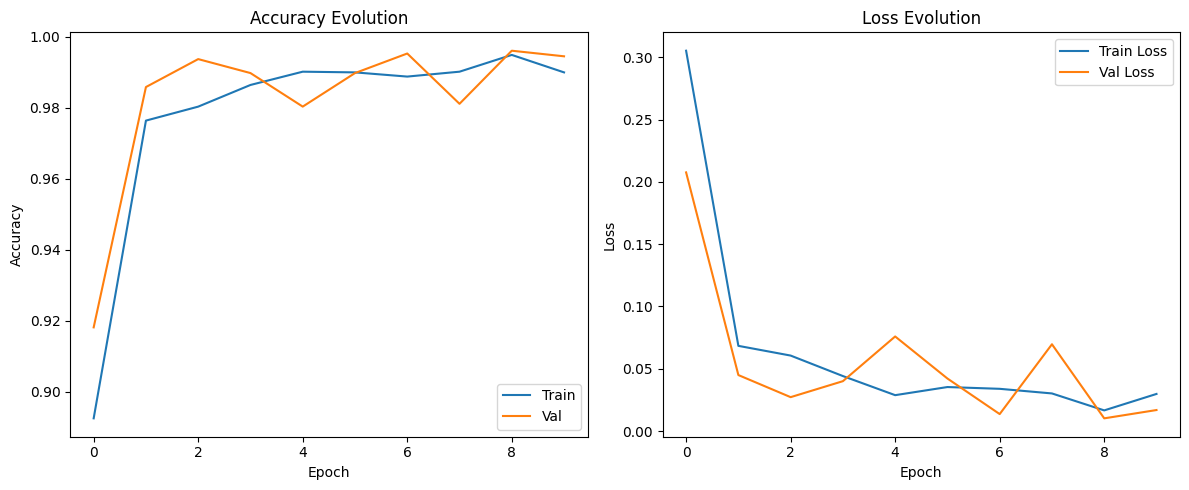

Final Train Acc: 99.00%
Final Val   Acc: 99.45%

Test Set Evaluation:
 Test Accuracy: 99.61%


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# ---------------------------
# Configuration
# ---------------------------
folder1_path = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/_CAD_FUSED_IMAGES"    # Class 0: CAD
folder2_path = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/_HC_FUSED_IMAGES"    # Class 1: Healthy
folder3_path = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/_MI_FUSED_IMAGES"    # Class 2: MI
folder4_path = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/_CHF_FUSED_IMAGES"    # Class 3: CHF
folder5_path = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/_ARR_FUSED_IMAGES"    # Class 3: ARR

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
EPOCHS     = 10
MODEL_PATH = "Multi_classification_model.h5"

# ---------------------------
# Enhanced Data Loading with Class Distribution Analysis
# ---------------------------
def load_data_with_analysis(folder1, folder2, folder3, folder4, folder5):
    class0_files = [f for f in os.listdir(folder1) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    class1_files = [f for f in os.listdir(folder2) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    class2_files = [f for f in os.listdir(folder3) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    class3_files = [f for f in os.listdir(folder4) if f.lower().endswith(('.png','.jpg','.jpeg'))]
    class4_files = [f for f in os.listdir(folder5) if f.lower().endswith(('.png','.jpg','.jpeg'))]

    print(f"Class 0 samples: {len(class0_files)}")
    print(f"Class 1 samples: {len(class1_files)}")
    print(f"Class 2 samples: {len(class2_files)}")
    print(f"Class 3 samples: {len(class3_files)}")
    print(f"Class 4 samples: {len(class4_files)}")
    total = len(class0_files) + len(class1_files) + len(class2_files) + len(class3_files) + len(class4_files)
    print(f"Total samples:   {total}\n")

    paths, labels = [], []
    for f in class0_files:
        paths.append(os.path.join(folder1, f)); labels.append(0)
    for f in class1_files:
        paths.append(os.path.join(folder2, f)); labels.append(1)
    for f in class2_files:
        paths.append(os.path.join(folder3, f)); labels.append(2)
    for f in class3_files:
        paths.append(os.path.join(folder4, f)); labels.append(3)
    for f in class4_files:
        paths.append(os.path.join(folder5, f)); labels.append(4)

    return paths, labels

paths, labels = load_data_with_analysis(folder1_path, folder2_path, folder3_path, folder4_path, folder5_path)

# ---------------------------
# Stratified Train/Test Split
# ---------------------------
train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

train_labels_ = np.array(train_labels)
test_labels_  = np.array(test_labels)

print("Training distribution:")
for i in range(4):
    print(f" - Class {i}: {np.sum(train_labels_==i)}")
print()
print("Test distribution:")
for i in range(4):
    print(f" - Class {i}: {np.sum(test_labels_==i)}")
print()

# ---------------------------
# Class Weights
# ---------------------------
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0,1,2,3,4]),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))
print(f"Class weights: {class_weights}\n")

# ---------------------------
# Data Pipeline
# ---------------------------
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

def create_dataset(paths, labels, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if is_training:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True, seed=SEED)
    ds = ds.map(lambda p, l: (tf.io.read_file(p), l), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda content, l: (
                    tf.image.decode_image(content,
                                          channels=3,
                                          expand_animations=False),
                    l
                ),
                num_parallel_calls=tf.data.AUTOTUNE)
    if is_training:
        ds = ds.map(lambda img, l: (tf.image.random_flip_left_right(img, seed=SEED), l),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, l: (tf.image.random_brightness(img, 0.2, seed=SEED), l),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda img, l: (tf.image.random_contrast(img, 0.7, 1.3, seed=SEED), l),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = create_dataset(train_paths, train_labels, is_training=True)
test_ds  = create_dataset(test_paths,  test_labels)

# ---------------------------
# Model Definition
# ---------------------------
def build_model():
    base = ResNet50(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE,3))
    for layer in base.layers[:100]:
        layer.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(5, activation='softmax')(x)  # Changed to 5 classes

    m = Model(inputs=base.input, outputs=out)
    m.compile(
        optimizer=optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

model = build_model()
model.summary()

# ---------------------------
# Callbacks (with checkpoint)
# ---------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10,
    mode='max', restore_best_weights=True, verbose=1
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2,
    patience=5, min_lr=1e-7, verbose=1
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    MODEL_PATH, monitor='val_accuracy',
    save_best_only=True, mode='max', verbose=1
)

# ---------------------------
# Training
# ---------------------------
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Save final model
model.save(MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}\n")

# ---------------------------
# Results Visualization
# ---------------------------
def analyze_results(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'],    label='Train')
    plt.plot(history.history['val_accuracy'],label='Val')
    plt.title('Accuracy Evolution')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'],    label='Train Loss')
    plt.plot(history.history['val_loss'],label='Val Loss')
    plt.title('Loss Evolution')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

    plt.tight_layout()
    plt.show()

    ft = history.history['accuracy'][-1]
    fv = history.history['val_accuracy'][-1]
    print(f"Final Train Acc: {ft:.2%}")
    print(f"Final Val   Acc: {fv:.2%}")

analyze_results(history)

# ---------------------------
# Test Set Evaluation
# ---------------------------
print("\nTest Set Evaluation:")
test_res = model.evaluate(test_ds, verbose=0)
print(f" Test Accuracy: {test_res[1]:.2%}")


In [ ]:
model.save("/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Binary Classification Training/_ARR_CHF_HC_MI_CAD_class_model.h5")
print(f"\nFinal model saved\n")


Final model saved



## **2.3** MODEL EVALUATION (ON TEST DATA)

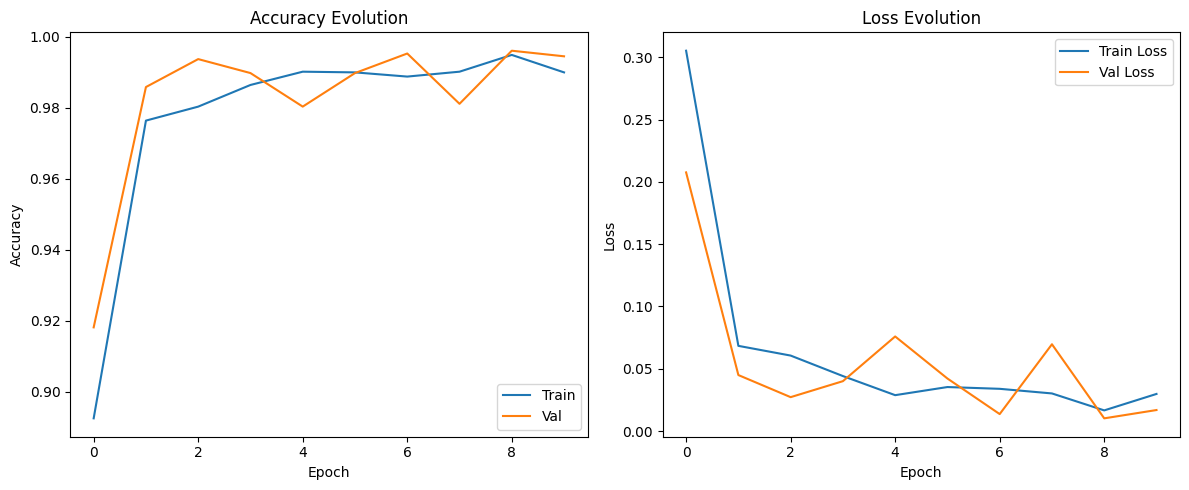

Final Train Accuracy: 99.00%
Final Val   Accuracy: 99.45%

Test Set Evaluation:
 Test Accuracy: 99.61%


In [ ]:
# ---------------------------
# Results Visualization
# ---------------------------
def analyze_results(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'],    label='Train')
    plt.plot(history.history['val_accuracy'],label='Val')
    plt.title('Accuracy Evolution')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'],    label='Train Loss')
    plt.plot(history.history['val_loss'],label='Val Loss')
    plt.title('Loss Evolution')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

    plt.tight_layout()
    plt.show()

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc   = history.history['val_accuracy'][-1]
    print(f"Final Train Accuracy: {final_train_acc:.2%}")
    print(f"Final Val   Accuracy: {final_val_acc:.2%}")

analyze_results(history)

# ---------------------------
# Test Set Evaluation
# ---------------------------
print("\nTest Set Evaluation:")
test_res = model.evaluate(test_ds, verbose=0)
print(f" Test Accuracy: {test_res[1]:.2%}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 343ms/step
Confusion Matrix:
 [[290   0   0   0   0]
 [  0 270   1   0   0]
 [  0   1 277   1   0]
 [  1   0   1 222   0]
 [  0   0   0   0 207]]

Classification Report:
              precision    recall  f1-score   support

         CAD     0.9966    1.0000    0.9983       290
     Healthy     0.9963    0.9963    0.9963       271
          MI     0.9928    0.9928    0.9928       279
         CHF     0.9955    0.9911    0.9933       224
         ARR     1.0000    1.0000    1.0000       207

    accuracy                         0.9961      1271
   macro avg     0.9962    0.9960    0.9961      1271
weighted avg     0.9961    0.9961    0.9961      1271



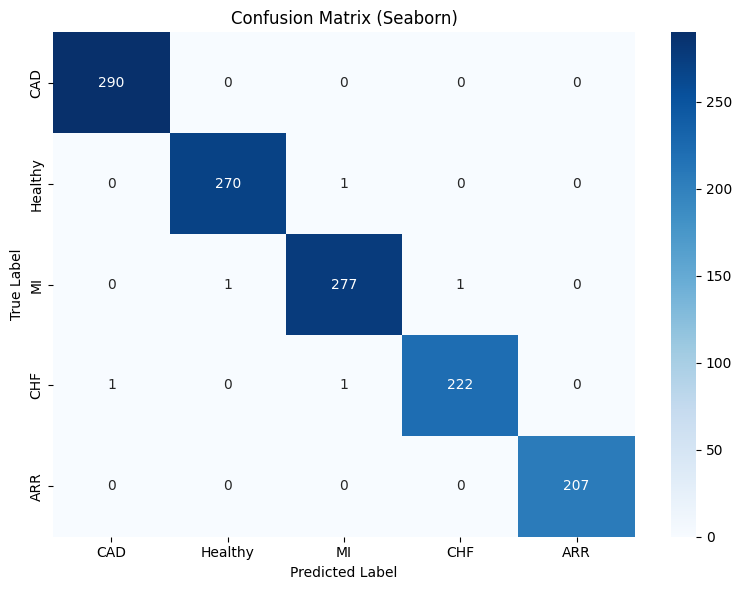

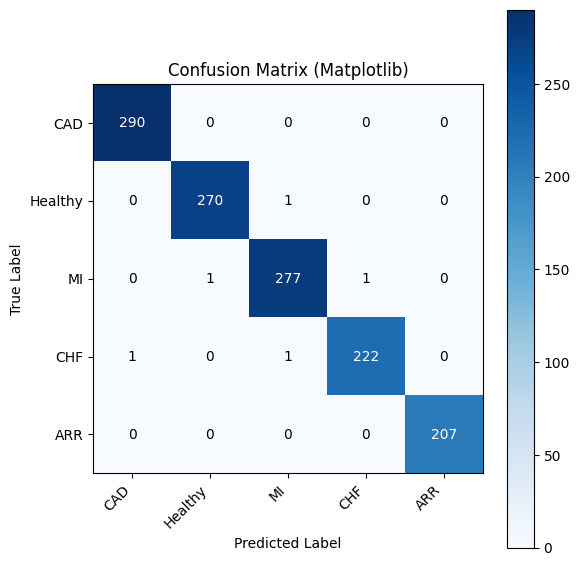

In [ ]:
# Put this at the very top of your notebook to force static, inline plots:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Define class labels (update according to your classification problem)
labels = ['CAD', 'Healthy', 'MI', 'CHF', 'ARR']

# Assuming test_labels_ is your ground truth and model is your trained model
y_true = test_labels_
y_pred = np.argmax(model.predict(test_ds), axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# Plot using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Seaborn)')
plt.tight_layout()
plt.show()

# Plot using matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Matplotlib)')
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
plt.yticks(np.arange(len(labels)), labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Annotate cells
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.colorbar()
plt.tight_layout()
plt.show()
